## EJERCICIO PRACTICO CLASE 3

GRUPO 4 - INTEGRANTES
- DARIO WLADIMIR HERRERA CHÁVEZ
- SANTIAGO PAUL GUALLICHICO ATI
- ROBINSON  DAMIAN CHILUISA GALLARDO

## FASE I 

## 1. Descricion del Trabajo
Utilice el dataset de cáncer de mama (Diagnostic Wisconsin Breast Cancer Database, WBCD) donde tenemos los datos de 569 mujeres. Cada mujer está descrita por 32 atributos. El primero es un identificador, el segundo el tipo de cáncer (Maligno o Benigno) y el resto son características numéricas extraídas de imágenes de biopsias de tejido mamario. Se pretende aprender el tipo de cáncer de mama (maligno=1, benigno=0), utilizando previamente el algoritmo PCA para reducción de dimensiones. Luego realizar un agrupamiento usando K-Means y comparar los clusters obtenidos con los componentes principales de PCA. En este conjunto de datos la distribución de clases es: 357 benignos y 212 malignos

### 1.1 Modelos de clasificación evaluados con PCA=2

Se evaluaron los siguientes algoritmos de clasificación supervisada:

- LR: Regresión Logística
- K-NN: K-Nearest Neighbors
- NB: Naive Bayes
- DT: Árbol de Decisión
- RF: Random Forest
- ANN: Red Neuronal Artificial (MLP)
- SVM: Support Vector Machine


## 2. Objetivo y alcance del trabajo
Esta práctica tiene el objetivo de realizar la predicción del tipo de cáncer de mama (maligno=1, benigno=0) utilizando el algoritmo de reducciones de dimensiones PCA y los algoritmos de clasificación revisados anteriormente, así como realizar tareas de agrupamiento (clustering) y la evaluación de los algoritmos usando las métricas y gráficas respectivas. Al finalizar la práctica, los maestrantes podrán entender el impacto de usar PCA en el dataset.


## 3. Desarrollo del trabajo

### 3.1 Importación de Liberias y metricas 

Se realiza la importación de las librerías y métricas necesarias para el desarrollo del modelo de machine learning, incluyendo herramientas para manipulación de datos, preprocesamiento, reducción de dimensionalidad, entrenamiento de algoritmos de clasificación y evaluación del desempeño mediante diferentes métricas.

In [20]:
# =========================================
# 3.1. IMPORTACIÓN DE LIBRERÍAS Y METRICAS
# =========================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# IMPORTACIÓN DE MÉTRICAS
# =========================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

### 3.2 Carga del Dataset

Se realiza la carga del dataset de cáncer de mama utilizando la función load_breast_cancer(). Posteriormente, se separan las variables independientes (X), que contienen las características del conjunto de datos, y la variable dependiente (y), que representa las clases objetivo (0 = maligno, 1 = benigno), para su uso en el entrenamiento del modelo de clasificación.

In [21]:
# =========================================
# 3.2. CARGA DEL DATASET
# =========================================

data = load_breast_cancer()
X = data.data
y = data.target  # 0 = Maligno | 1 = Benigno

### 3.3 Train /Test Split

Se realiza la división del dataset en conjuntos de entrenamiento y prueba utilizando train_test_split. El 80% de los datos se asigna al entrenamiento y el 20% al test, asegurando una partición estratificada según la variable objetivo (stratify=y) para mantener la proporción de clases. Además, se establece un random_state para garantizar la reproducibilidad de los resultados

In [22]:
# =========================================
# 3.3. TRAIN / TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 3.4 Escalado de Datos

Se realiza el escalado de los datos utilizando StandardScaler, con el objetivo de estandarizar las variables del conjunto de datos. Primero se ajusta el escalador con los datos de entrenamiento (fit_transform) y luego se aplica la misma transformación al conjunto de prueba (transform), garantizando que ambos queden en la misma escala para mejorar el rendimiento de los modelos de machine learning.

In [23]:
# =========================================
# 3.4. ESCALADO DE DATOS
# =========================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.5 PCA = 2 componentes

Se aplica el análisis de componentes principales (PCA) con el objetivo de reducir la dimensionalidad de los datos a 2 componentes principales. Primero se ajusta el modelo con el conjunto de entrenamiento escalado (fit_transform) y luego se transforma el conjunto de prueba (transform), permitiendo conservar la mayor cantidad de información posible en menos variables para facilitar la visualización y el entrenamiento de los modelos.

In [24]:
# =========================================
# 3.5. PCA (2 COMPONENTES)
# =========================================

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

### 3.6 Visualizacion PCA

Se realiza la visualización del conjunto de entrenamiento después de aplicar PCA con 2 componentes principales. Los datos se separan según su clase (maligno y benigno) y se representan en un gráfico de dispersión, donde cada punto corresponde a una muestra proyectada en el espacio reducido. Esto permite observar de forma visual la distribución de las clases y su posible separabilidad en las dos dimensiones principales

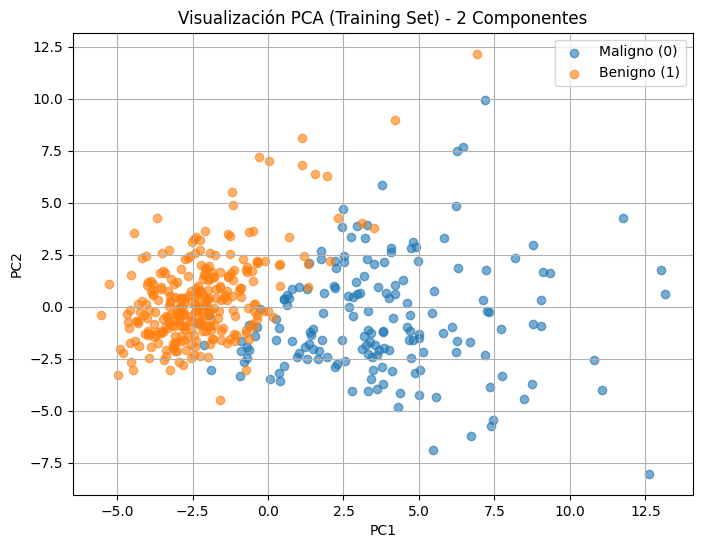

In [25]:
# =========================================
# 3.6. VISUALIZACIÓN PCA (TRAINING SET)
# =========================================

X_maligno = X_train_pca[y_train == 0]
X_benigno = X_train_pca[y_train == 1]

plt.figure(figsize=(8, 6))
plt.scatter(X_maligno[:, 0], X_maligno[:, 1], alpha=0.6, label="Maligno (0)")
plt.scatter(X_benigno[:, 0], X_benigno[:, 1], alpha=0.6, label="Benigno (1)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualización PCA (Training Set) - 2 Componentes")
plt.legend()
plt.grid(True)
plt.show()

### 3.7  Definicion de los Modelos

Se definen distintos modelos de clasificación supervisada que serán utilizados para el análisis del dataset. Se incluyen algoritmos como Regresión Logística, K-Nearest Neighbors, Naive Bayes, Árboles de Decisión, Random Forest, Redes Neuronales (MLP) y Support Vector Machine (SVM). Todos los modelos se almacenan en un diccionario para facilitar su entrenamiento, evaluación y comparación posterior.

In [26]:
# =========================================
# 3.7. DEFINICIÓN DE MODELOS
# =========================================

modelos = {
    "LR": LogisticRegression(max_iter=1000),
    "K-NN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "DT": DecisionTreeClassifier(random_state=42),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "ANN": MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf")
}

###  3.8 Evaluacion de metricas

Se realiza el entrenamiento y evaluación de múltiples modelos de clasificación definidos previamente. Para cada modelo se ajusta el entrenamiento con los datos escalados, se realizan predicciones sobre el conjunto de prueba y, en caso de ser posible, se calculan probabilidades para obtener el área bajo la curva ROC (AUC).

Posteriormente, se calculan diferentes métricas de desempeño como accuracy, precision, recall y F1-score. Todos los resultados se almacenan en una lista y finalmente se organizan en una tabla para comparar el rendimiento de cada modelo en el conjunto de prueba.

In [27]:
# =========================================
# 3.8 MÉTRICAS PARA CADA MODELO
# =========================================

metricas = []

for nombre, modelo in modelos.items():

    # ---- Entrenar modelo ----
    modelo.fit(X_train_scaled, y_train)

    # ---- Predicciones ----
    y_pred = modelo.predict(X_test_scaled)

    # ---- Probabilidades (para ROC AUC) ----
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan  # algunos modelos no soportan predict_proba

    # ---- Métricas ----
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metricas.append([
        nombre,
        round(acc, 3),
        round(prec, 3),
        round(rec, 3),
        round(f1, 3),
        round(auc, 3) if not np.isnan(auc) else "N/A"
    ])

# =========================================
# TABLA FINAL DE MÉTRICAS
# =========================================

df_metricas = pd.DataFrame(
    metricas,
    columns=[
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC AUC"
    ]
)

print("\nMÉTRICAS POR MODELO (TEST SET)\n")
print(df_metricas)


MÉTRICAS POR MODELO (TEST SET)

  Modelo  Accuracy  Precision  Recall  F1-score ROC AUC
0     LR     0.982      0.986   0.986     0.986   0.995
1   K-NN     0.956      0.959   0.972     0.966   0.979
2     NB     0.930      0.944   0.944     0.944   0.987
3     DT     0.912      0.956   0.903     0.929   0.916
4     RF     0.956      0.959   0.972     0.966   0.994
5    ANN     0.956      0.986   0.944     0.965   0.994
6    SVM     0.982      0.986   0.986     0.986     N/A


### 3.9 Entrenamiento y Evaluacion

Se realiza el entrenamiento y evaluación de los modelos de clasificación tanto sin reducción de dimensionalidad como utilizando PCA con 2 componentes. Para cada modelo, se entrena primero con los datos escalados originales y luego con los datos reducidos mediante PCA, calculando la exactitud (accuracy) en ambos casos.

Además, se guardan los modelos entrenados en archivos .pkl utilizando joblib, y se registra el tamaño de cada modelo en memoria. Finalmente, los resultados de rendimiento y tamaño de los modelos se almacenan en una lista para su posterior análisis y comparación.

In [28]:
# =========================================
# 3.9. ENTRENAMIENTO Y EVALUACIÓN
# =========================================

resultados = []
os.makedirs("modelos", exist_ok=True)

for nombre, modelo in modelos.items():

    # ----- SIN PCA -----
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    archivo = f"modelos/{nombre}_sin_pca.pkl"
    joblib.dump(modelo, archivo)
    size_kb = os.path.getsize(archivo) / 1024

    # ----- CON PCA (2) -----
    modelo_pca = modelo.__class__(**modelo.get_params())
    modelo_pca.fit(X_train_pca, y_train)
    y_pred_pca = modelo_pca.predict(X_test_pca)
    acc_pca = accuracy_score(y_test, y_pred_pca)

    archivo_pca = f"modelos/{nombre}_pca_2.pkl"
    joblib.dump(modelo_pca, archivo_pca)
    size_kb_pca = os.path.getsize(archivo_pca) / 1024

    resultados.append([
        nombre,
        round(acc, 3),
        round(size_kb, 1),
        round(acc_pca, 3),
        round(size_kb_pca, 1)
    ])

### 3.10 Comparacion de Modelos con y sin PCA 
Se realiza una comparación del rendimiento de distintos modelos de clasificación utilizando la métrica de accuracy, tanto con datos originales como con datos reducidos mediante PCA (2 componentes). Para ello, se generan gráficos de barras que permiten visualizar de forma clara el impacto de la reducción de dimensionalidad en el desempeño de cada modelo, facilitando la comparación entre ambas condiciones.

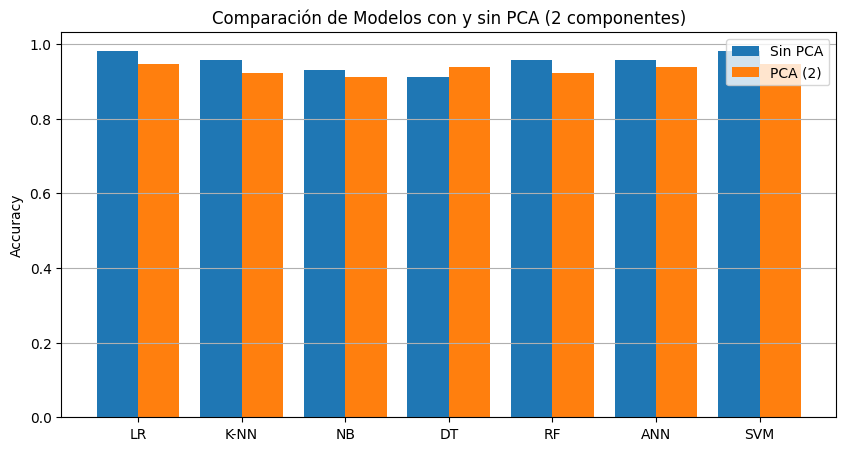

In [29]:
# =========================================
# 3.10 COMPARACIÓN CON LOS RESULTADOS YA CALCULADOS
# =========================================

import numpy as np
import matplotlib.pyplot as plt

labels = [r[0] for r in resultados]

acc_no_pca = [r[1] for r in resultados]
acc_pca_2 = [r[3] for r in resultados]

x = np.arange(len(labels))

plt.figure(figsize=(10,5))

plt.bar(x - 0.2, acc_no_pca, width=0.4, label="Sin PCA")
plt.bar(x + 0.2, acc_pca_2, width=0.4, label="PCA (2)")

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Comparación de Modelos con y sin PCA (2 componentes)")
plt.legend()
plt.grid(axis="y")
plt.show()

### 3.11 Tabla de Resultado 

Se construye una tabla final con los resultados obtenidos de cada modelo de clasificación, tanto sin PCA como con PCA de 2 componentes. Esta tabla incluye la exactitud (accuracy) y el tamaño del modelo en kilobytes en ambos casos, permitiendo comparar el rendimiento y la eficiencia de los modelos de forma resumida y estructurada. Finalmente, se imprime la tabla con todos los resultados finales.

In [31]:
# =========================================
# 3.11. TABLA FINAL DE RESULTADOS
# =========================================

df_resultados = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "ACC",
        "KB (sin PCA)",
        "ACC PCA(2)",
        "KB PCA(2)"
    ]
)

print("\nRESULTADOS FINALES\n")
print(df_resultados)


RESULTADOS FINALES

  Modelo    ACC  KB (sin PCA)  ACC PCA(2)  KB PCA(2)
0     LR  0.982           1.0       0.947        0.8
1   K-NN  0.956         111.0       0.921       23.7
2     NB  0.930           1.7       0.912        0.8
3     DT  0.912           4.2       0.939        6.5
4     RF  0.956         316.7       0.921      478.6
5    ANN  0.956          60.7       0.939       14.6
6    SVM  0.982          26.2       0.947        4.7


## 4. Análisis de Resultados y Comparación por Modelo

A continuación se presenta un análisis comparativo de los modelos evaluados **con y sin PCA (2 componentes)**, considerando dos criterios clave:

- **Rendimiento predictivo** → Accuracy (ACC)  
- **Costo computacional** → Tamaño del modelo en KB (KB)


### 4.1 Interpretación General

El uso de **PCA con 2 componentes** introduce una **reducción drástica de dimensionalidad**, lo que tiene dos efectos principales:

1. **Reducción del tamaño del modelo** (memoria / almacenamiento).
2. **Ligera disminución de la exactitud**, aunque en algunos modelos se mantiene competitiva o incluso mejora.

Esto permite analizar el **trade-off entre precisión y eficiencia**.



### 4.2 Comparación Modelo por Modelo

| Modelo | ACC sin PCA | KB sin PCA | ACC PCA (2) | KB PCA (2) | Análisis del impacto de PCA |
|------|-------------|------------|-------------|------------|-----------------------------|
| LR   | 0.982 | 1.0   | 0.947 | 0.8   | Ligera pérdida de precisión con leve mejora en tamaño |
| K-NN | 0.956 | 111.0 | 0.921 | 23.7  | Reducción muy significativa del tamaño con caída moderada de ACC |
| NB   | 0.930 | 1.7   | 0.912 | 0.8   | Disminución leve de precisión y mejora en eficiencia |
| DT   | 0.912 | 4.2   | 0.939 | 6.5   | Mejora de precisión con incremento del tamaño del modelo |
| RF   | 0.956 | 316.7 | 0.921 | 478.6 | PCA afecta negativamente tanto precisión como tamaño |
| ANN  | 0.956 | 60.7  | 0.939 | 14.6  | Fuerte reducción de tamaño con pérdida mínima de precisión |
| SVM  | 0.982 | 26.2  | 0.947 | 4.7   | Gran reducción de tamaño con disminución moderada de ACC |



## 5. Conclusiones

- Los modelos con **mayor exactitud sin PCA** son **Regresión Logística** y **SVM**.
- **K-NN, ANN y SVM** son los modelos que **más se benefician del uso de PCA (2 componentes)** en términos de eficiencia.
- **Random Forest** no se beneficia del uso de PCA, ya que empeora tanto el rendimiento como el tamaño del modelo.
- El **mejor balance entre precisión y eficiencia usando PCA** se observa en **ANN y SVM**, lo que los hace adecuados para escenarios con restricciones de recursos.



---
---

## FASE II

K-MEANS EN CÁNCER DE MAMA (K=2 vs K=3)


## 1. Descripción del trabajo

En este trabajo se realiza un análisis de agrupamiento no supervisado utilizando el algoritmo K-Means aplicado al dataset de cáncer de mama. Primero se realiza la estandarización de los datos para garantizar que todas las variables tengan la misma escala y evitar sesgos en el cálculo de distancias.

Posteriormente, se aplica reducción de dimensionalidad mediante PCA con el objetivo de facilitar la visualización de los datos en dos dimensiones.

Se entrena el modelo K-Means con dos configuraciones distintas: K=2 y K=3. Para cada caso se calculan métricas de evaluación internas como el Silhouette Score, el índice de Calinski-Harabasz y el índice de Davies-Bouldin, con el fin de medir la cohesión y separación de los clústeres generados.

Finalmente, se comparan los resultados obtenidos y se analiza cuál número de clústeres representa mejor la estructura del dataset, considerando tanto las métricas como la interpretabilidad de los resultados.

## 2. Objetivo del trabajo

Aplicar el algoritmo de agrupamiento K-Means sobre el dataset de cáncer de mama con el fin de identificar patrones naturales en los datos sin utilizar las etiquetas de clase. Se busca comparar el rendimiento del modelo utilizando K=2 y K=3, evaluar la calidad de los clústeres mediante métricas internas y determinar cuál configuración ofrece una mejor representación de la estructura del conjunto de datos.



## 3. Desarrollo del Trabajo


 MÉTRICAS PARA K=2
Silhouette Score: 0.3434
Calinski-Harabasz: 267.69
Davies-Bouldin: 1.3205
Inercia: 11595.53

 MÉTRICAS PARA K=3
Silhouette Score: 0.3144
Calinski-Harabasz: 197.11
Davies-Bouldin: 1.5294
Inercia: 10061.80


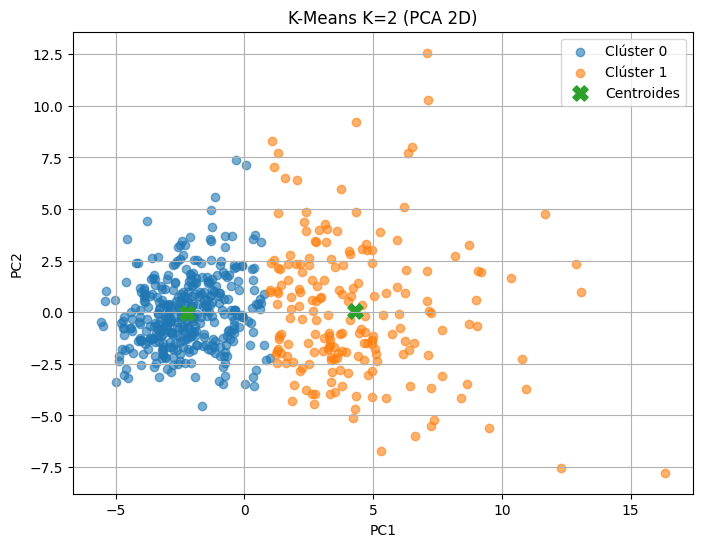

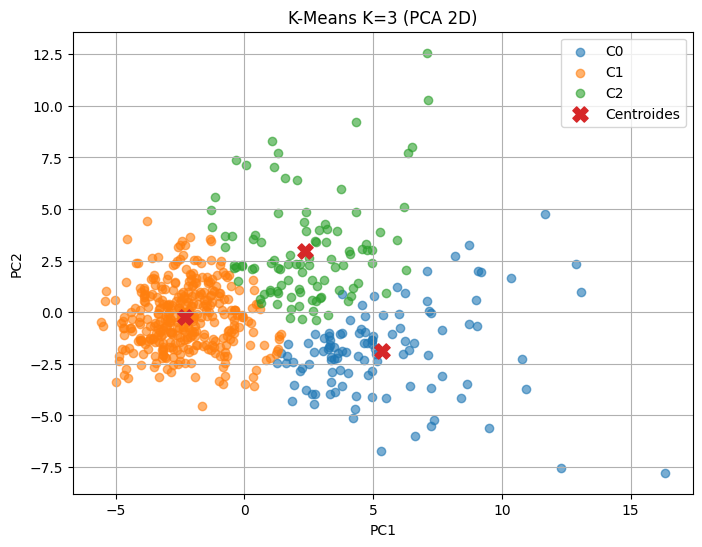


 COMPARACIÓN FINAL

K=2
Silhouette: 0.3434, CH: 267.69, DB: 1.3205, Inercia: 11595.53

K=3
Silhouette: 0.3144, CH: 197.11, DB: 1.5294, Inercia: 10061.80

 Relación con clases reales
Real: [212 357]
Clusters K=2: [375 194]


In [38]:
# =========================================
# K-MEANS EN CÁNCER DE MAMA (K=2 vs K=3)
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# =========================================
# 1. CARGA DE DATOS
# =========================================
data = load_breast_cancer()
X = data.data
y = data.target  # 0 = maligno, 1 = benigno

# =========================================
# 2. ESCALADO
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================
# 3. PCA (2 COMPONENTES PARA VISUALIZACIÓN)
# =========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =========================================
# 4. FUNCIÓN DE EVALUACIÓN
# =========================================
def evaluar_modelo(X, modelo, labels, nombre="K"):
    print(f"\n MÉTRICAS PARA {nombre}")

    sil = silhouette_score(X, labels)
    cal = calinski_harabasz_score(X, labels)
    dav = davies_bouldin_score(X, labels)
    iner = modelo.inertia_

    print(f"Silhouette Score: {sil:.4f}")
    print(f"Calinski-Harabasz: {cal:.2f}")
    print(f"Davies-Bouldin: {dav:.4f}")
    print(f"Inercia: {iner:.2f}")

    return sil, cal, dav, iner

# =========================================
# 5. K-MEANS K=2
# =========================================
k2 = KMeans(n_clusters=2, init="k-means++", random_state=42, n_init=10)
labels2 = k2.fit_predict(X_scaled)

sil2, cal2, dav2, iner2 = evaluar_modelo(X_scaled, k2, labels2, "K=2")

# =========================================
# 6. K-MEANS K=3
# =========================================
k3 = KMeans(n_clusters=3, init="k-means++", random_state=42, n_init=10)
labels3 = k3.fit_predict(X_scaled)

sil3, cal3, dav3, iner3 = evaluar_modelo(X_scaled, k3, labels3, "K=3")

# =========================================
# 7. VISUALIZACIÓN EN PCA (K=2)
# =========================================
centroides2 = pca.transform(k2.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(X_pca[labels2 == 0, 0], X_pca[labels2 == 0, 1],
            label="Clúster 0", alpha=0.6)

plt.scatter(X_pca[labels2 == 1, 0], X_pca[labels2 == 1, 1],
            label="Clúster 1", alpha=0.6)

plt.scatter(centroides2[:,0], centroides2[:,1],
            marker="X", s=120, label="Centroides")

plt.title("K-Means K=2 (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

# =========================================
# 8. VISUALIZACIÓN EN PCA (K=3)
# =========================================
centroides3 = pca.transform(k3.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(X_pca[labels3 == 0, 0], X_pca[labels3 == 0, 1], label="C0", alpha=0.6)
plt.scatter(X_pca[labels3 == 1, 0], X_pca[labels3 == 1, 1], label="C1", alpha=0.6)
plt.scatter(X_pca[labels3 == 2, 0], X_pca[labels3 == 2, 1], label="C2", alpha=0.6)

plt.scatter(centroides3[:,0], centroides3[:,1],
            marker="X", s=120, label="Centroides")

plt.title("K-Means K=3 (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

# =========================================
# 9. COMPARACIÓN FINAL
# =========================================
print("\n COMPARACIÓN FINAL")

print("\nK=2")
print(f"Silhouette: {sil2:.4f}, CH: {cal2:.2f}, DB: {dav2:.4f}, Inercia: {iner2:.2f}")

print("\nK=3")
print(f"Silhouette: {sil3:.4f}, CH: {cal3:.2f}, DB: {dav3:.4f}, Inercia: {iner3:.2f}")

# =========================================
# 10. RELACIÓN CON CLASE REAL (REFERENCIA)
# =========================================
print("\n Relación con clases reales")
print("Real:", np.bincount(y))
print("Clusters K=2:", np.bincount(labels2))

## 4. Analisis de Resultados – K-Means en Cancer de Mama (K=2 vs K=3)

### 4.1. Resumen de metricas obtenidas

Para K=2  
Silhouette Score: 0.3434  
Calinski-Harabasz: 267.69  
Davies-Bouldin: 1.3205  
Inercia: 11595.53  

Para K=3  
Silhouette Score: 0.3144  
Calinski-Harabasz: 197.11  
Davies-Bouldin: 1.5294  
Inercia: 10061.80  

### 4.2. Analisis de K=2

El modelo con K=2 presenta los mejores resultados globales considerando el conjunto de metricas evaluadas.

El Silhouette Score de 0.3434 indica una separacion moderada entre los clusters, lo que sugiere que los grupos formados poseen una coherencia interna aceptable y una separacion razonable entre ellos.

El indice de Calinski-Harabasz de 267.69 es elevado, lo que refleja una buena relacion entre la dispersion inter-cluster y la dispersion intra-cluster, indicando una estructura de agrupamiento bien definida.

El indice de Davies-Bouldin de 1.3205 es relativamente bajo, lo que implica que los clusters son menos similares entre si y presentan una mejor definicion.

La inercia obtenida para K=2 es de 11595.53. Este valor representa la suma de las distancias cuadradas de los puntos a sus centroides correspondientes y refleja el nivel de compacidad de los clusters. Aunque la inercia no puede interpretarse de forma aislada, este valor es consistente con un agrupamiento estable y coherente para dos clusters.

En conjunto, K=2 muestra una estructura de agrupamiento solida y alineada con la naturaleza del dataset.

### 4.3. Analisis de K=3

Para K=3 se observa un deterioro general en el rendimiento del modelo.

El Silhouette Score disminuye a 0.3144, lo que indica que los clusters son menos compactos y estan peor separados en comparacion con K=2.

El indice de Calinski-Harabasz baja a 197.11, lo que refleja una reduccion en la calidad de la separacion entre clusters y una menor cohesion interna.

El indice de Davies-Bouldin aumenta a 1.5294, indicando una mayor similitud entre los clusters y una peor definicion de los grupos.

La inercia se reduce a 10061.80, lo cual es un comportamiento esperado al incrementar el numero de clusters. Sin embargo, esta disminucion no se traduce en una mejora real del agrupamiento, ya que las demas metricas muestran un empeoramiento de la calidad global.

Estos resultados sugieren que el tercer cluster introduce una fragmentacion innecesaria de los datos sin aportar una representacion mas clara de su estructura.

### 4.4. Comparacion entre K=2 y K=3

Al comparar ambos modelos, K=2 supera consistentemente a K=3 en todas las metricas de calidad del agrupamiento.

K=2 presenta un mayor Silhouette Score, un indice Calinski-Harabasz mas alto y un indice Davies-Bouldin mas bajo, lo que indica clusters mas compactos y mejor separados.

Aunque K=3 presenta una menor inercia, esta reduccion se debe exclusivamente al aumento del numero de clusters y no a una mejora real en la estructura del agrupamiento, por lo que no constituye un criterio suficiente para justificar su eleccion.

### 4.5. Conclusiones

El modelo K-Means con K=2 es el mas adecuado para este problema, ya que ofrece el mejor equilibrio entre compacidad y separacion de los clusters, y se alinea con la estructura natural del dataset de cancer de mama, el cual contiene dos clases principales.

El modelo con K=3 no mejora la representacion de los datos y genera una fragmentacion innecesaria, por lo que no es recomendable para este caso.

---
---

## 5. Modelo  GMM (GAUSSIAN MIXTURE MODEL)

In [39]:
import numpy as np
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# =========================================
# CARGA DE DATOS
# =========================================
data = load_breast_cancer()
X = data.data
y = data.target  # 0 = maligno, 1 = benigno

# =========================================
# ESCALADO
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================
# PCA (solo para análisis posterior)
# =========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =========================================
# FUNCIÓN DE EVALUACIÓN (con inercia)
# =========================================
def evaluar_modelo(X, labels, modelo, nombre="Modelo"):
    sil = silhouette_score(X, labels)
    cal = calinski_harabasz_score(X, labels)
    dav = davies_bouldin_score(X, labels)

    # Inercia aproximada (GMM no usa centroides)
    inertia = 0.0
    for i in range(modelo.n_components):
        puntos_cluster = X[labels == i]
        centro = modelo.means_[i]
        inertia += np.sum((puntos_cluster - centro) ** 2)

    print(f"\n MÉTRICAS PARA {nombre}")
    print(f"Silhouette Score: {sil:.4f}")
    print(f"Calinski-Harabasz: {cal:.2f}")
    print(f"Davies-Bouldin: {dav:.4f}")
    print(f"Inercia (aprox): {inertia:.2f}")

    return sil, cal, dav, inertia

# =========================================
# GMM CON 2 COMPONENTES
# =========================================
gmm2 = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

labels_gmm2 = gmm2.fit_predict(X_scaled)
sil_gmm2, cal_gmm2, dav_gmm2, iner_gmm2 = evaluar_modelo(
    X_scaled, labels_gmm2, gmm2, "GMM (2)"
)

# =========================================
# GMM CON 3 COMPONENTES
# =========================================
gmm3 = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

labels_gmm3 = gmm3.fit_predict(X_scaled)
sil_gmm3, cal_gmm3, dav_gmm3, iner_gmm3 = evaluar_modelo(
    X_scaled, labels_gmm3, gmm3, "GMM (3)"
)

# =========================================
# GUARDAR MODELOS
# =========================================
joblib.dump(gmm2, "gmm_2.pkl")
joblib.dump(gmm3, "gmm_3.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")


 MÉTRICAS PARA GMM (2)
Silhouette Score: 0.3145
Calinski-Harabasz: 247.28
Davies-Bouldin: 1.3770
Inercia (aprox): 11886.15

 MÉTRICAS PARA GMM (3)
Silhouette Score: 0.2515
Calinski-Harabasz: 171.76
Davies-Bouldin: 1.7297
Inercia (aprox): 10622.77


['pca.pkl']

## 6. Comparacion K-MEANS VS GMM

In [40]:

# Resultados previamente obtenidos de K-Means y GMM
resultados = {
    "Modelo": ["K-Means (2)", "K-Means (3)", "GMM (2)", "GMM (3)"],
    "Silhouette": [sil2, sil3, sil_gmm2, sil_gmm3],
    "Calinski-Harabasz": [cal2, cal3, cal_gmm2, cal_gmm3],
    "Davies-Bouldin": [dav2, dav3, dav_gmm2, dav_gmm3],
    "Inercia": [iner2, iner3, iner_gmm2, iner_gmm3]
}

df_comparacion = pd.DataFrame(resultados)

print("\n TABLA COMPARATIVA DE MODELOS")
print(df_comparacion)


 TABLA COMPARATIVA DE MODELOS
        Modelo  Silhouette  Calinski-Harabasz  Davies-Bouldin       Inercia
0  K-Means (2)    0.343382         267.691716        1.320510  11595.526607
1  K-Means (3)    0.314384         197.114000        1.529388  10061.797818
2      GMM (2)    0.314489         247.283500        1.377034  11886.146350
3      GMM (3)    0.251499         171.763441        1.729708  10622.768357


## 7. Analisis comparativa de modelos K MEANS y GMM

### Resultados obtenidos

| Modelo     | Silhouette | Calinski Harabasz | Davies Bouldin | Inercia  |
|------------|------------|-------------------|----------------|----------|
| K Means 2  | 0.3434     | 267.69            | 1.3205         | 11595.53 |
| K Means 3  | 0.3144     | 197.11            | 1.5294         | 10061.80 |
| GMM 2      | 0.3145     | 247.28            | 1.3770         | 11886.15 |
| GMM 3      | 0.2515     | 171.76            | 1.7297         | 10622.77 |

### 7.1 Analisis por metrica

#### Silhouette Score

El valor mas alto corresponde a K Means con dos clusters. Esto indica una mejor relacion entre la cohesion interna de los grupos y la separacion entre ellos. Aunque GMM con dos componentes presenta un valor cercano, su resultado es inferior, lo que evidencia mayor solapamiento entre clusters.

Al incrementar el numero de clusters a tres, ambos modelos muestran una disminucion del Silhouette Score, lo que indica una peor definicion de los grupos.

#### Calinski Harabasz

El mayor valor se obtiene con K Means 2. Esta metrica penaliza la fragmentacion innecesaria, por lo que la reduccion del valor al usar tres clusters indica que la division adicional no aporta una mejora estructural en los datos.

#### Davies Bouldin

El menor valor corresponde a K Means 2, lo que indica clusters mas compactos y mejor separados. En GMM 2 el valor es mayor, reflejando una separacion menos clara. En ambos modelos, el uso de tres clusters incrementa esta metrica, evidenciando un empeoramiento del agrupamiento.

#### Inercia

La menor inercia se obtiene al usar tres clusters, tanto en K Means como en GMM. Sin embargo, esta reduccion es esperable al aumentar el numero de clusters y no implica necesariamente un mejor modelo. K Means 2 mantiene una inercia mayor, pero logra mejores metricas globales de separacion y cohesion.

### 7.2 Comparacion entre K Means y GMM

K Means con dos clusters presenta el mejor desempeno global considerando todas las metricas evaluadas. Sus valores superiores en Silhouette y Calinski Harabasz, junto con un menor Davies Bouldin, indican una estructura de agrupamiento mas clara y estable.

GMM con dos componentes ofrece una representacion probabilistica mas flexible que permite solapamiento entre grupos. No obstante, esta flexibilidad se refleja en metricas internas ligeramente inferiores y una inercia mayor, lo que indica menor definicion de los clusters frente a K Means.

### 7.3 Impacto de usar tres clusters

En ambos algoritmos, el aumento a tres clusters reduce el Silhouette Score y el indice Calinski Harabasz, mientras incrementa el indice Davies Bouldin. Aunque la inercia disminuye, este comportamiento responde a una mayor fragmentacion del espacio y no a una mejora real del agrupamiento.

### 7.4 Conclusion final

De acuerdo con las metricas internas de validacion y considerando la inercia, el modelo K Means con dos clusters presenta el mejor desempeno global. Genera clusters mas compactos y mejor separados, coherentes con la estructura natural del conjunto de datos de cancer de mama. El uso de GMM aporta una interpretacion probabilistica interesante, pero no supera a K Means en calidad de agrupamiento. El uso de tres clusters no resulta adecuado para este conjunto de datos

## 8. Aplicacion en el campo laboral 

### Dario Herrera
Como profesional del sector de pagos electrónicos, una posible evolución de este proyecto sería fortalecer los sistemas de detección de fraude mediante algoritmos de aprendizaje automático. Se podrían utilizar Árboles de Decisión para generar reglas de riesgo explicables, SVM para mejorar la clasificación de transacciones fraudulentas y Redes Neuronales para detectar patrones complejos en tiempo real. Además, PCA permitiría reducir la dimensionalidad de los datos para optimizar el rendimiento de los modelos, mientras que K-Means facilitaría el agrupamiento de clientes, comercios o transacciones con comportamientos similares, ayudando a identificar anomalías y posibles fraudes. Esto contribuiría a mejorar el Fraud Scoring, reducir falsos positivos y reforzar la seguridad sin afectar la experiencia del cliente.

### Santiago Guallichico

### Robinson Chiluisa

En un data center, PCA y K-Means se utilizan para analizar grandes volúmenes de datos generados por servidores, sistemas de enfriamiento, energía y sensores ambientales.
El PCA se usa para reducir la cantidad de variables del sistema sin perder información importante. Esto permite simplificar el análisis de datos como temperatura, consumo eléctrico y carga de servidores, facilitando la detección de patrones y comportamientos anómalos.
K-Means se utiliza para agrupar equipos o estados operativos similares. Por ejemplo, permite clasificar servidores según su nivel de carga, identificar zonas con alta temperatura o agrupar patrones de consumo energético.
La combinación de PCA y K-Means ayuda a simplificar la información del data center y a identificar patrones útiles para mejorar la eficiencia, detectar anomalías y optimizar el uso de recursos.